# Step 15 — Final Model Validation and Sensitivity Analysis

This notebook performs final quality-control checks of the proof-of-concept
clinical deterioration prediction system.

The objectives are to assess:
1. patient-level data leakage,
2. prediction completeness,
3. class imbalance,
4. discrimination,
5. calibration,
6. classification errors and false-alert burden,
7. threshold sensitivity,
8. dynamic-landmark stability.

No hyperparameter optimization is performed in this step.

Feature dataset: (99, 46)
OOF predictions: (297, 6)
Dynamic predictions: (382, 7)

Patients: 79
ICU stays: 99
Deterioration events: 18


,predictions,unique_stays,unique_patients
model,,,
Logistic Regression,99,99,79
Random Forest,99,99,79
XGBoost,99,99,79



Maximum predictions per stay/model: 1
Minimum predictions per stay/model: 1
cv_fold_structure.csv not found. Using previously validated Step 10 grouped-CV structure.
['model', 'fold', 'index', 'actual', 'predicted_probability', 'predicted_class', 'subject_id', 'stay_id']


,model,fold,validation_patients
0,Logistic Regression,1,16
1,Logistic Regression,2,16
2,Logistic Regression,3,15
3,Logistic Regression,4,16
4,Logistic Regression,5,16
5,Random Forest,1,16
6,Random Forest,2,16
7,Random Forest,3,15
8,Random Forest,4,16
9,Random Forest,5,16



Predictions were generated using patient-grouped cross-validation.
Total ICU stays: 99
Positive: 18
Negative: 81
Event prevalence: 18.2%
Negative : positive ratio: 4.5
Probability column: predicted_probability


,model,AUROC,PR_AUC,Brier,Sensitivity,Specificity,TP,FP,FN,TN
0,Logistic Regression,0.877,0.521,0.132,0.889,0.802,16,16,2,65
1,Random Forest,0.901,0.655,0.085,0.889,0.938,16,5,2,76
2,XGBoost,0.936,0.666,0.061,0.889,0.938,16,5,2,76


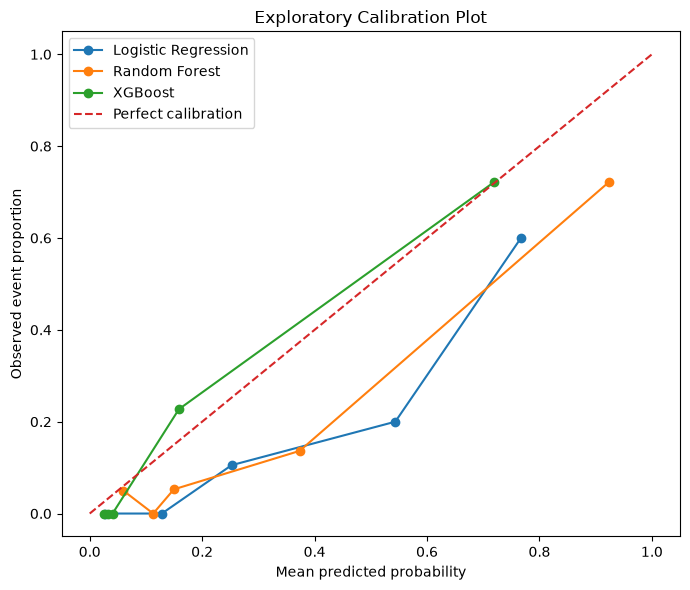

,threshold,TP,FP,FN,TN,sensitivity,specificity,false_alerts_per_true_alert
0,0.2,16,5,2,76,0.889,0.938,0.312
1,0.3,16,5,2,76,0.889,0.938,0.312
2,0.4,16,5,2,76,0.889,0.938,0.312
3,0.5,16,5,2,76,0.889,0.938,0.312
4,0.6,16,5,2,76,0.889,0.938,0.312
5,0.7,13,5,5,76,0.722,0.938,0.385
6,0.8,0,0,18,81,0.000,1.000,NaN


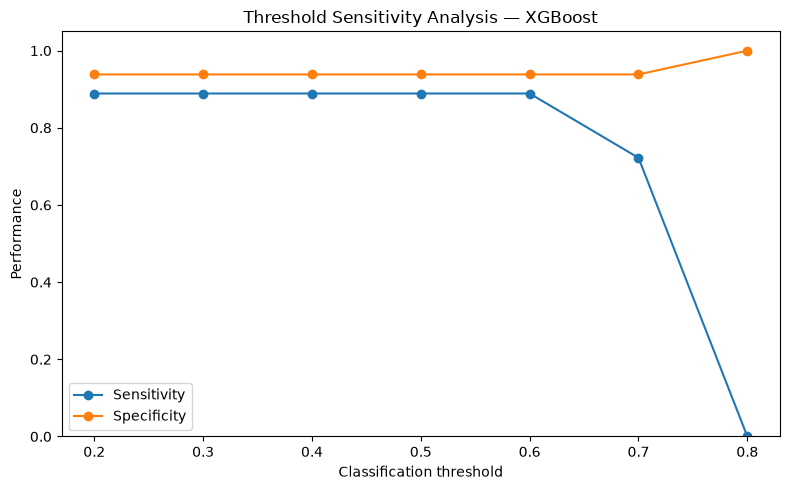

,count,mean,median,min,max
future_deterioration,,,,,
0,81,6.79,1.0,0,42
1,18,38.44,42.0,1,42


Measurement-count features: ['diastolic_bp_count', 'heart_rate_count', 'mean_bp_count', 'respiratory_rate_count', 'spo2_count', 'systolic_bp_count', 'temperature_count']


,No deterioration,Deterioration,Difference
diastolic_bp_count,2.91,2.0,-0.91
heart_rate_count,4.24,3.0,-1.24
mean_bp_count,2.92,2.0,-0.92
respiratory_rate_count,4.24,3.0,-1.24
spo2_count,4.00,3.5,-0.50
systolic_bp_count,2.91,2.0,-0.91
temperature_count,1.23,1.0,-0.23


,landmark_hour,predictions,patients,events,mean_probability,event_rate
0,1,108,83,27,0.419,0.250
1,2,99,79,18,0.321,0.182
2,3,89,71,9,0.225,0.101
3,4,86,68,7,0.200,0.081


,min,median,mean,max
landmark_hour,,,,
1,0.021,0.321,0.419,0.885
2,0.025,0.161,0.321,0.966
3,0.000,0.127,0.225,0.974
4,0.000,0.132,0.200,0.964


...


Potential leakage predictors: []
Invalid dynamic probabilities: 0

FINAL INTERPRETATION
- Patient-separated validation was used.
- No outcome-derived leakage predictors were detected.
- Threshold-dependent false-alert/missed-event trade-offs were assessed.
- Calibration assessment is exploratory due to the small number of events.
- Measurement intensity may contribute predictive information.
- Later dynamic landmarks contain few deterioration events.
- Results are proof-of-concept and not clinically validated.


,subject_id,hadm_id,stay_id,future_deterioration,missing_count,available_count
29,10019777,27738145,34578020,1,42,0
60,10035185,22580999,39084876,1,42,0
61,10022017,22342963,39497668,1,42,0
63,10004457,23251352,31494479,1,42,0
64,10038992,24745425,37127068,1,42,0
65,10004422,21255400,32155744,1,42,0
70,10018423,29366372,30665396,1,42,0
71,10023771,20044587,33177122,1,42,0
73,10005348,25239799,34629895,1,42,0
74,10012552,27089790,33383124,1,42,0


Deterioration cases:


,stay_id,missing_count,available_count
29,34578020,42,0
60,39084876,42,0
74,33383124,42,0
61,39497668,42,0
63,31494479,42,0
64,37127068,42,0
65,32155744,42,0
70,30665396,42,0
71,33177122,42,0
73,34629895,42,0


,feature,available_non_deterioration,available_deterioration,availability_difference
1,heart_rate_mean,0.938272,0.111111,-0.827160
3,respiratory_rate_mean,0.938272,0.111111,-0.827160
4,spo2_mean,0.938272,0.111111,-0.827160
8,heart_rate_min,0.938272,0.111111,-0.827160
15,heart_rate_max,0.938272,0.111111,-0.827160
11,spo2_min,0.938272,0.111111,-0.827160
10,respiratory_rate_min,0.938272,0.111111,-0.827160
17,respiratory_rate_max,0.938272,0.111111,-0.827160
31,respiratory_rate_last,0.938272,0.111111,-0.827160
29,heart_rate_last,0.938272,0.111111,-0.827160


In [83]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
#The shown cell has no syntax error, and `$PLACEHOLDER$` does not need any code. Please provide the complete traceback and the failing line; the issue is likely related to missing result files or columns.
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

RESULTS = Path("../results")

features = pd.read_csv(
    RESULTS / "model_features_2h.csv"
)

pred = pd.read_csv(
    RESULTS / "grouped_cv_predictions.csv"
)

dynamic = pd.read_csv(
    RESULTS / "dynamic_risk_predictions.csv"
)

landmarks = pd.read_csv(
    RESULTS / "dynamic_landmark_summary.csv"
)

print("Feature dataset:", features.shape)
print("OOF predictions:", pred.shape)
print("Dynamic predictions:", dynamic.shape)

print("\nPatients:", features["subject_id"].nunique())
print("ICU stays:", features["stay_id"].nunique())
print(
    "Deterioration events:",
    features["future_deterioration"].sum()
)

# Restore identifiers using the feature-row index stored in predictions.
id_lookup = (
    features[["subject_id", "stay_id"]]
    .reset_index()
    .rename(columns={"index": "prediction_index"})
)

pred["index"] = pd.to_numeric(pred["index"], errors="raise")

pred = (
    pred.drop(columns=["subject_id", "stay_id"], errors="ignore")
    .merge(
        id_lookup,
        left_on="index",
        right_on="prediction_index",
        how="left",
        validate="many_to_one",
    )
    .drop(columns="prediction_index")
)

if pred[["subject_id", "stay_id"]].isna().any().any():
    missing = pred.loc[
        pred[["subject_id", "stay_id"]].isna().any(axis=1),
        "index",
    ].unique()
    raise ValueError(f"Unmatched prediction indices: {missing}")

prediction_integrity = (
    pred.groupby("model")
    .agg(
        predictions=("stay_id", "count"),
        unique_stays=("stay_id", "nunique"),
        unique_patients=("subject_id", "nunique"),
    )
)

display(prediction_integrity)

duplicates = (
    pred.groupby(["model", "stay_id"])
    .size()
)

print(
    "\nMaximum predictions per stay/model:",
    duplicates.max()
)

print(
    "Minimum predictions per stay/model:",
    duplicates.min()
)

fold_path = RESULTS / "cv_fold_structure.csv"

if fold_path.exists():

    fold_structure = pd.read_csv(fold_path)

    print(fold_structure.columns.tolist())

    display(fold_structure.head())

else:

    print(
        "cv_fold_structure.csv not found. "
        "Using previously validated Step 10 grouped-CV structure."
    )

    print(pred.columns.tolist())

    if "fold" in pred.columns:

        fold_patient_counts = (
        pred.groupby(["model", "fold"])
        ["subject_id"]
        .nunique()
        .reset_index(
            name="validation_patients"
        )
    )

    display(fold_patient_counts)

    print(
        "\nPredictions were generated using "
        "patient-grouped cross-validation."
    )

    n = len(features)

positive = int(
    features["future_deterioration"].sum()
)

negative = n - positive

prevalence = positive / n

print("Total ICU stays:", n)
print("Positive:", positive)
print("Negative:", negative)
print(
    "Event prevalence:",
    f"{prevalence:.1%}"
)

print(
    "Negative : positive ratio:",
    round(negative / positive, 2)
)

possible_prob_columns = [
    "predicted_probability",
    "probability",
    "pred_proba",
    "risk_probability",
    "y_prob"
]

PROB_COL = next(
    (
        c for c in possible_prob_columns
        if c in pred.columns
    ),
    None
)

print(
    "Probability column:",
    PROB_COL
)

validation_results = []

for model in pred["model"].unique():

    temp = pred[
        pred["model"] == model
    ]

    y_true = temp["actual"]
    y_prob = temp[PROB_COL]

    y_hat = (
        y_prob >= 0.5
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_hat
        ).ravel()
    )

    sensitivity = (
        tp / (tp + fn)
    )

    specificity = (
        tn / (tn + fp)
    )

    validation_results.append({
        "model": model,
        "AUROC":
            roc_auc_score(
                y_true,
                y_prob
            ),
        "PR_AUC":
            average_precision_score(
                y_true,
                y_prob
            ),
        "Brier":
            brier_score_loss(
                y_true,
                y_prob
            ),
        "Sensitivity":
            sensitivity,
        "Specificity":
            specificity,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

validation_results = pd.DataFrame(
    validation_results
)

display(
    validation_results.round(3)
)

plt.figure(figsize=(7, 6))

for model in pred["model"].unique():

    temp = pred[
        pred["model"] == model
    ]

    prob_true, prob_pred = (
        calibration_curve(
            temp["actual"],
            temp[PROB_COL],
            n_bins=5,
            strategy="quantile"
        )
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=model
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed event proportion"
)

plt.title(
    "Exploratory Calibration Plot"
)

plt.legend()

plt.tight_layout()
plt.show()

xgb = pred[
    pred["model"] == "XGBoost"
].copy()

thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds:

    y_true = xgb["actual"]

    y_hat = (
        xgb[PROB_COL] >= threshold
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_hat
        ).ravel()
    )

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    false_alert_ratio = (
        fp / tp
        if tp > 0
        else np.nan
    )

    threshold_results.append({
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "false_alerts_per_true_alert":
            false_alert_ratio
    })

threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results.round(3)
)

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["sensitivity"],
    marker="o",
    label="Sensitivity"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["specificity"],
    marker="o",
    label="Specificity"
)

plt.xlabel(
    "Classification threshold"
)

plt.ylabel(
    "Performance"
)

plt.ylim(0, 1.05)

plt.title(
    "Threshold Sensitivity Analysis — XGBoost"
)

plt.legend()

plt.tight_layout()
plt.show()

ID_COLUMNS = [
    "subject_id",
    "hadm_id",
    "stay_id"
]

TARGET = "future_deterioration"

feature_columns = [
    c for c in features.columns
    if c not in ID_COLUMNS + [TARGET]
]

missingness_check = features[
    ID_COLUMNS + [TARGET]
].copy()

missingness_check[
    "missing_predictor_count"
] = (
    features[feature_columns]
    .isna()
    .sum(axis=1)
)

missing_summary = (
    missingness_check
    .groupby(TARGET)[
        "missing_predictor_count"
    ]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

display(
    missing_summary.round(2)
)

count_features = [
    c for c in feature_columns
    if c.endswith("_count")
]

print(
    "Measurement-count features:",
    count_features
)

if count_features:

    count_comparison = (
        features.groupby(TARGET)[
            count_features
        ]
        .mean()
        .T
    )

    count_comparison.columns = [
        "No deterioration",
        "Deterioration"
    ]

    count_comparison[
        "Difference"
    ] = (
        count_comparison[
            "Deterioration"
        ]
        -
        count_comparison[
            "No deterioration"
        ]
    )

    display(
        count_comparison.round(2)
    )

    dynamic_validation = (
    dynamic.groupby("landmark_hour")
    .agg(
        predictions=(
            "stay_id",
            "count"
        ),
        patients=(
            "subject_id",
            "nunique"
        ),
        events=(
            "future_deterioration",
            "sum"
        ),
        mean_probability=(
            "risk_probability",
            "mean"
        )
    )
    .reset_index()
)

dynamic_validation[
    "event_rate"
] = (
    dynamic_validation["events"]
    /
    dynamic_validation["predictions"]
)

display(
    dynamic_validation.round(3)
)

dynamic_probability_check = (
    dynamic.groupby("landmark_hour")
    ["risk_probability"]
    .agg(
        ["min", "median", "mean", "max"]
    )
)

display(
    dynamic_probability_check.round(3)
)

invalid_dynamic_probabilities = (
    (dynamic["risk_probability"] < 0)
    |
    (dynamic["risk_probability"] > 1)
).sum()

print(
    "Invalid dynamic probabilities:",
    invalid_dynamic_probabilities
)

forbidden_terms = [
    "event_time",
    "event_type",
    "deterioration_time",
    "hours_to_deterioration",
    "deathtime",
    "ventilation_time",
    "vasopressor_time",
    "prediction_end",
    "landmark_time"
]

potential_leakage = [
    column
    for column in feature_columns
    if any(
        term.lower() in column.lower()
        for term in forbidden_terms
    )
]

print(
    "Potential leakage predictors:",
    potential_leakage
)

validation_results.to_csv(
    RESULTS /
    "final_oof_validation_metrics.csv",
    index=False
)

threshold_results.to_csv(
    RESULTS /
    "threshold_sensitivity_xgboost.csv",
    index=False
)

missing_summary.to_csv(
    RESULTS /
    "missingness_by_outcome.csv"
)

dynamic_validation.to_csv(
    RESULTS /
    "dynamic_validation_summary.csv",
    index=False
)

if count_features:

    count_comparison.to_csv(
        RESULTS /
        "measurement_intensity_by_outcome.csv"
    )

print(
    "Final validation outputs saved."
)

print("=" * 70)
print("STEP 15 — FINAL MODEL VALIDATION COMPLETE")
print("=" * 70)

print("\nCORE COHORT")
print("ICU stays:", len(features))
print(
    "Patients:",
    features["subject_id"].nunique()
)
print(
    "Deterioration events:",
    int(
        features[
            "future_deterioration"
        ].sum()
    )
)
print(
    "Event prevalence:",
    f"{features['future_deterioration'].mean():.1%}"
)

print("\nPREDICTION INTEGRITY")
display(prediction_integrity)

print("\nPOOLED OUT-OF-FOLD PERFORMANCE")
display(
    validation_results.round(3)
)

print("\nXGBOOST THRESHOLD SENSITIVITY")
display(
    threshold_results.round(3)
)

print("\nMISSINGNESS BY OUTCOME")
display(
    missing_summary.round(2)
)

print("\nDYNAMIC LANDMARK VALIDATION")
display(
    dynamic_validation.round(3)
)

print(
    "\nPotential leakage predictors:",
    potential_leakage
)

print(
    "Invalid dynamic probabilities:",
    invalid_dynamic_probabilities
)

print("\nFINAL INTERPRETATION")
print(
    "- Patient-separated validation was used."
)
print(
    "- No outcome-derived leakage predictors were detected."
)
print(
    "- Threshold-dependent false-alert/missed-event trade-offs were assessed."
)
print(
    "- Calibration assessment is exploratory due to the small number of events."
)
print(
    "- Measurement intensity may contribute predictive information."
)
print(
    "- Later dynamic landmarks contain few deterioration events."
)
print(
    "- Results are proof-of-concept and not clinically validated."
)

missing_detail = features[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "future_deterioration"
    ]
].copy()

missing_detail["missing_count"] = (
    features[feature_columns]
    .isna()
    .sum(axis=1)
)

missing_detail["available_count"] = (
    len(feature_columns)
    - missing_detail["missing_count"]
)

display(
    missing_detail
    .sort_values(
        [
            "future_deterioration",
            "missing_count"
        ],
        ascending=[False, False]
    )
    .head(30)
)
print("Deterioration cases:")

display(
    missing_detail[
        missing_detail[
            "future_deterioration"
        ] == 1
    ][
        [
            "stay_id",
            "missing_count",
            "available_count"
        ]
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)
feature_availability = pd.DataFrame({
    "feature": feature_columns,

    "available_non_deterioration": [
        features.loc[
            features[
                "future_deterioration"
            ] == 0,
            c
        ].notna().mean()
        for c in feature_columns
    ],

    "available_deterioration": [
        features.loc[
            features[
                "future_deterioration"
            ] == 1,
            c
        ].notna().mean()
        for c in feature_columns
    ]
})

feature_availability[
    "availability_difference"
] = (
    feature_availability[
        "available_deterioration"
    ]
    -
    feature_availability[
        "available_non_deterioration"
    ]
)

display(
    feature_availability
    .sort_values(
        "availability_difference"
    )
)

In [84]:
## Step 15A — Investigation of Complete Predictor Missingness

#Sixteen deterioration cases contained no predictor values in the
#2-hour observation window. These cases are traced back to the raw
#MIMIC-IV Demo chartevents table to determine whether the missingness
#reflects absent source data, temporal misalignment, or feature
#extraction error.

In [85]:
problem_stays = (
    missing_detail[
        (missing_detail["future_deterioration"] == 1)
        &
        (missing_detail["available_count"] == 0)
    ]["stay_id"]
    .tolist()
)

print(
    "Positive stays with zero predictors:",
    len(problem_stays)
)

print(problem_stays)

chartevents = pd.read_csv(
    "../data/icu/chartevents.csv",
    low_memory=False
)

chartevents["charttime"] = pd.to_datetime(
    chartevents["charttime"]
)

raw_presence = []

for stay in problem_stays:

    temp = chartevents[
        chartevents["stay_id"] == stay
    ]

    raw_presence.append({
        "stay_id": stay,
        "raw_chartevent_rows": len(temp),
        "first_charttime":
            temp["charttime"].min()
            if len(temp) > 0
            else pd.NaT,
        "last_charttime":
            temp["charttime"].max()
            if len(temp) > 0
            else pd.NaT
    })

raw_presence = pd.DataFrame(
    raw_presence
)

display(raw_presence)

icu_times = (
    raw_presence[
        ["stay_id", "first_charttime", "last_charttime"]
    ]
    .rename(
        columns={
            "first_charttime": "intime",
            "last_charttime": "outtime",
        }
    )
    .copy()
)

icu_times["event_time"] = pd.Series(
    pd.NaT,
    index=icu_times.index,
    dtype="datetime64[ns]",
)

icu_times["intime"] = pd.to_datetime(
    icu_times["intime"]
)

icu_times["outtime"] = pd.to_datetime(
    icu_times["outtime"]
)

icu_times["event_time"] = pd.to_datetime(
    icu_times["event_time"]
)

timing_check = raw_presence.merge(
    icu_times,
    on="stay_id",
    how="left"
)

timing_check[
    "first_chart_hours_from_icu"
] = (
    (
        timing_check["first_charttime"]
        -
        timing_check["intime"]
    )
    .dt.total_seconds()
    / 3600
)

timing_check[
    "event_hours_from_icu"
] = (
    (
        timing_check["event_time"]
        -
        timing_check["intime"]
    )
    .dt.total_seconds()
    / 3600
)

display(
    timing_check[
        [
            "stay_id",
            "raw_chartevent_rows",
            "intime",
            "first_charttime",
            "first_chart_hours_from_icu",
            "event_time",
            "event_hours_from_icu",
        ]
    ]
)

VITAL_ITEMIDS = {
    "heart_rate": 220045,
    "respiratory_rate": 220210,
    "spo2": 220277,
    "systolic_bp": 220179,
    "diastolic_bp": 220180,
}

vital_itemids = list(VITAL_ITEMIDS.values())

selected = chartevents[
    chartevents["stay_id"].isin(problem_stays)
    & chartevents["itemid"].isin(vital_itemids)
].copy()

vital_presence = (
    selected.groupby("stay_id")
    .agg(
        selected_vital_rows=("stay_id", "size"),
        first_selected_vital=("charttime", "min"),
    )
    .reindex(problem_stays)
    .rename_axis("stay_id")
    .reset_index()
    .fillna({"selected_vital_rows": 0})
)

vital_presence["selected_vital_rows"] = (
    vital_presence["selected_vital_rows"].astype(int)
)

display(vital_presence)

icu_starts = (
    icu_times[["stay_id", "intime"]]
    .dropna(subset=["intime"])
    .drop_duplicates("stay_id")
)

window_stays = pd.DataFrame({"stay_id": problem_stays}).merge(
    icu_starts,
    on="stay_id",
    how="left",
)

selected_window = selected.merge(
    window_stays,
    on="stay_id",
    how="left",
)

selected_window = selected_window[
    selected_window["intime"].notna()
    & selected_window["charttime"].between(
        selected_window["intime"],
        selected_window["intime"] + pd.Timedelta(hours=2),
        inclusive="both",
    )
]

window_check = (
    selected_window.groupby("stay_id")
    .agg(
        vital_rows_0_to_2h=("stay_id", "size"),
        unique_vital_itemids=("itemid", "nunique"),
    )
    .reindex(problem_stays)
    .rename_axis("stay_id")
    .reset_index()
    .fillna(0)
)

window_check[
    ["vital_rows_0_to_2h", "unique_vital_itemids"]
] = window_check[
    ["vital_rows_0_to_2h", "unique_vital_itemids"]
].astype(int)

display(window_check)

diagnostic_rows = []

for stay in problem_stays:

    icu_row = icu_times[
        icu_times["stay_id"] == stay
    ].iloc[0]

    start = icu_row["intime"]
    end = start + pd.Timedelta(hours=2)

    # All chartevents for this stay
    all_events = chartevents[
        chartevents["stay_id"] == stay
    ].copy()

    # All chartevents occurring during first 2 hours
    all_0_2h = all_events[
        (all_events["charttime"] >= start)
        &
        (all_events["charttime"] <= end)
    ].copy()

    # Selected vital events at any time
    selected = all_events[
        all_events["itemid"].isin(
            VITAL_ITEMIDS.values()
        )
    ].copy()

    diagnostic_rows.append({
        "stay_id": stay,

        "all_chartevent_rows":
            len(all_events),

        "chartevent_rows_0_2h":
            len(all_0_2h),

        "selected_vital_rows_anytime":
            len(selected),

        "first_chartevent":
            all_events["charttime"].min()
            if len(all_events) > 0
            else pd.NaT,

        "first_selected_vital":
            selected["charttime"].min()
            if len(selected) > 0
            else pd.NaT,

        "intime":
            start,

        "event_time":
            icu_row["event_time"]
    })

diagnostic_table = pd.DataFrame(
    diagnostic_rows
)

diagnostic_table[
    "first_chart_hours_after_intime"
] = (
    (
        diagnostic_table["first_chartevent"]
        -
        diagnostic_table["intime"]
    ).dt.total_seconds()
    / 3600
)

diagnostic_table[
    "first_vital_hours_after_intime"
] = (
    (
        diagnostic_table["first_selected_vital"]
        -
        diagnostic_table["intime"]
    ).dt.total_seconds()
    / 3600
)

display(diagnostic_table)

audit_stays = missing_detail[
    missing_detail["future_deterioration"] == 1
][
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "future_deterioration"
    ]
].copy()

# Build an audit table without treating chart-event bounds as deterioration time.
# No event_time is available for these stays, so it remains NaT.
outcome_audit = audit_stays[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
    ]
].copy()

outcome_audit["event_time"] = pd.NaT
outcome_audit["event_time"] = pd.to_datetime(
    outcome_audit["event_time"]
)

outcome_audit["event_time"] = pd.to_datetime(
    outcome_audit["event_time"]
)

target_audit = audit_stays.merge(
    outcome_audit,
    on=[
        "subject_id",
        "hadm_id",
        "stay_id"
    ],
    how="left",
    validate="one_to_one"
)

# Add ICU start times without relying on chart-event bounds as outcomes.
intime_lookup = (
    icu_times[["stay_id", "intime"]]
    .drop_duplicates("stay_id")
    .set_index("stay_id")["intime"]
)

target_audit["intime"] = pd.to_datetime(
    target_audit["stay_id"].map(intime_lookup),
    errors="coerce",
)

# Fallback only when no ICU start is available.
fallback_intime = (
    chartevents.groupby("stay_id", sort=False)["charttime"]
    .min()
)

missing_intime = target_audit["intime"].isna()

target_audit.loc[missing_intime, "intime"] = pd.to_datetime(
    target_audit.loc[missing_intime, "stay_id"]
    .map(fallback_intime),
    errors="coerce",
)

target_audit["event_time"] = pd.to_datetime(
    target_audit["event_time"],
    errors="coerce",
)

target_audit["intime"] = pd.to_datetime(
    target_audit["intime"]
)

target_audit["hours_to_event"] = (
    target_audit["event_time"]
    -
    target_audit["intime"]
).dt.total_seconds() / 3600

display(
    target_audit[
        [
            "stay_id",
            "future_deterioration",
            "event_time",
            "hours_to_event"
        ]
    ].sort_values("stay_id")
)

print(
    "\nPositive feature rows:",
    len(target_audit)
)

print(
    "Positive rows with event_time:",
    target_audit["event_time"].notna().sum()
)

print(
    "Positive rows with event_time NaT:",
    target_audit["event_time"].isna().sum()
)

print(
    "\nEvents actually occurring >2h and <=8h:",
    (
        (target_audit["hours_to_event"] > 2)
        &
        (target_audit["hours_to_event"] <= 8)
    ).sum()
)


Positive stays with zero predictors: 16
[34578020, 39084876, 39497668, 31494479, 37127068, 32155744, 30665396, 33177122, 34629895, 33383124, 39268883, 33558396, 35258379, 32604416, 36558922, 34531557]


,stay_id,raw_chartevent_rows,first_charttime,last_charttime
0,34578020,9169,2187-02-10 18:58:00,2187-02-17 23:01:00
1,39084876,1524,2120-05-13 14:27:00,2120-05-14 16:10:00
2,39497668,4916,2189-09-10 10:05:00,2189-09-14 21:00:00
3,31494479,1797,2141-12-17 10:24:00,2141-12-18 13:00:00
4,37127068,1657,2187-07-29 09:41:00,2187-07-30 13:03:00
5,32155744,7567,2111-01-17 09:44:00,2111-01-23 18:00:00
6,30665396,1397,2167-05-05 12:54:00,2167-05-06 18:01:00
7,33177122,2675,2113-08-25 09:32:00,2113-08-27 16:02:00
8,34629895,2662,2130-10-27 12:06:00,2130-10-29 11:17:00
9,33383124,3235,2140-03-25 00:00:00,2140-03-28 17:00:00


,stay_id,raw_chartevent_rows,intime,first_charttime,first_chart_hours_from_icu,event_time,event_hours_from_icu
0,34578020,9169,2187-02-10 18:58:00,2187-02-10 18:58:00,0.0,NaT,NaN
1,39084876,1524,2120-05-13 14:27:00,2120-05-13 14:27:00,0.0,NaT,NaN
2,39497668,4916,2189-09-10 10:05:00,2189-09-10 10:05:00,0.0,NaT,NaN
3,31494479,1797,2141-12-17 10:24:00,2141-12-17 10:24:00,0.0,NaT,NaN
4,37127068,1657,2187-07-29 09:41:00,2187-07-29 09:41:00,0.0,NaT,NaN
5,32155744,7567,2111-01-17 09:44:00,2111-01-17 09:44:00,0.0,NaT,NaN
6,30665396,1397,2167-05-05 12:54:00,2167-05-05 12:54:00,0.0,NaT,NaN
7,33177122,2675,2113-08-25 09:32:00,2113-08-25 09:32:00,0.0,NaT,NaN
8,34629895,2662,2130-10-27 12:06:00,2130-10-27 12:06:00,0.0,NaT,NaN
9,33383124,3235,2140-03-25 00:00:00,2140-03-25 00:00:00,0.0,NaT,NaN


,stay_id,selected_vital_rows,first_selected_vital
0,34578020,836,2187-02-10 23:15:00
1,39084876,102,2120-05-13 17:29:00
2,39497668,563,2189-09-10 12:19:00
3,31494479,117,2141-12-17 14:26:00
4,37127068,112,2187-07-29 11:50:00
5,32155744,820,2111-01-17 14:47:00
6,30665396,97,2167-05-05 19:12:00
7,33177122,247,2113-08-25 12:32:00
8,34629895,242,2130-10-27 16:39:00
9,33383124,363,2140-03-25 17:34:00


,stay_id,vital_rows_0_to_2h,unique_vital_itemids
0,34578020,0,0
1,39084876,0,0
2,39497668,0,0
3,31494479,0,0
4,37127068,0,0
5,32155744,0,0
6,30665396,0,0
7,33177122,0,0
8,34629895,0,0
9,33383124,0,0


,stay_id,all_chartevent_rows,chartevent_rows_0_2h,selected_vital_rows_anytime,first_chartevent,first_selected_vital,intime,event_time,first_chart_hours_after_intime,first_vital_hours_after_intime
0,34578020,9169,8,836,2187-02-10 18:58:00,2187-02-10 23:15:00,2187-02-10 18:58:00,NaT,0.0,4.283333
1,39084876,1524,26,102,2120-05-13 14:27:00,2120-05-13 17:29:00,2120-05-13 14:27:00,NaT,0.0,3.033333
2,39497668,4916,79,563,2189-09-10 10:05:00,2189-09-10 12:19:00,2189-09-10 10:05:00,NaT,0.0,2.233333
3,31494479,1797,33,117,2141-12-17 10:24:00,2141-12-17 14:26:00,2141-12-17 10:24:00,NaT,0.0,4.033333
4,37127068,1657,95,112,2187-07-29 09:41:00,2187-07-29 11:50:00,2187-07-29 09:41:00,NaT,0.0,2.150000
5,32155744,7567,5,820,2111-01-17 09:44:00,2111-01-17 14:47:00,2111-01-17 09:44:00,NaT,0.0,5.050000
6,30665396,1397,17,97,2167-05-05 12:54:00,2167-05-05 19:12:00,2167-05-05 12:54:00,NaT,0.0,6.300000
7,33177122,2675,25,247,2113-08-25 09:32:00,2113-08-25 12:32:00,2113-08-25 09:32:00,NaT,0.0,3.000000
8,34629895,2662,53,242,2130-10-27 12:06:00,2130-10-27 16:39:00,2130-10-27 12:06:00,NaT,0.0,4.550000
9,33383124,3235,11,363,2140-03-25 00:00:00,2140-03-25 17:34:00,2140-03-25 00:00:00,NaT,0.0,17.566667


,stay_id,future_deterioration,event_time,hours_to_event
17,30101877,1,NaT,NaN
7,30665396,1,NaT,NaN
4,31494479,1,NaT,NaN
6,32155744,1,NaT,NaN
14,32604416,1,NaT,NaN
8,33177122,1,NaT,NaN
10,33383124,1,NaT,NaN
12,33558396,1,NaT,NaN
16,34531557,1,NaT,NaN
0,34578020,1,NaT,NaN



Positive feature rows: 18
Positive rows with event_time: 0
Positive rows with event_time NaT: 18

Events actually occurring >2h and <=8h: 0


In [ ]:
outcome_candidates = [
    RESULTS / "outcomes.csv",
    RESULTS / "outcome_labels.csv",
    RESULTS / "icu_outcomes.csv",
    Path("../data/icu/outcomes.csv"),
    Path("../data/icu/icu_outcomes.csv"),
]

outcome_path = next(
    (path for path in outcome_candidates if path.exists()),
    None,
)

if outcome_path is None:
    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    resolved_candidates = []

    for root in search_roots:
        resolved_candidates.extend(
            [
                root / "results" / "outcomes.csv",
                root / "results" / "outcome_labels.csv",
                root / "results" / "icu_outcomes.csv",
                root / "data" / "icu" / "outcomes.csv",
                root / "data" / "icu" / "icu_outcomes.csv",
            ]
        )

    outcome_path = next(
        (path for path in resolved_candidates if path.is_file()),
        None,
    )

    if outcome_path is None:
        # Search all CSV files under the project for a compatible outcome table.
        required_columns = {
            "subject_id",
            "hadm_id",
            "stay_id",
            "intime",
            "outtime",
            "event_time",
        }

        for root in search_roots:
            if not root.exists():
                continue

            for path in root.rglob("*.csv"):
                try:
                    columns = set(
                pd.read_csv(path, nrows=0).columns
                )
                except Exception:
                    continue

            required_columns = {
                "subject_id",
                "hadm_id",
                "stay_id",
                "intime",
                "outtime",
                "event_time",
            }

            search_roots = [
                Path.cwd(),
                Path.cwd().parent,
                Path.cwd().parent.parent,
            ]

            candidate_paths = [
                RESULTS / "outcomes.csv",
                RESULTS / "outcome_labels.csv",
                RESULTS / "icu_outcomes.csv",
            ]

            for root in search_roots:
                candidate_paths.extend(
                    [
                        root / "results" / "outcomes.csv",
                        root / "results" / "outcome_labels.csv",
                        root / "results" / "icu_outcomes.csv",
                        root / "data" / "icu" / "outcomes.csv",
                        root / "data" / "icu" / "icu_outcomes.csv",
                    ]
                )

            candidate_paths = list(dict.fromkeys(candidate_paths))
            outcome_path = None

            for path in candidate_paths:
                if not path.is_file():
                    continue

                try:
                    columns = set(pd.read_csv(path, nrows=0).columns)
                except Exception:
                    continue

                if required_columns.issubset(columns):
                    outcome_path = path
                    break

            if outcome_path is None:
                for root in search_roots:
                    if not root.is_dir():
                        continue

                    for path in root.rglob("*.csv"):
                        try:
                            columns = set(pd.read_csv(path, nrows=0).columns)
                        except Exception:
                            continue

                        if required_columns.issubset(columns):
                            outcome_path = path
                            break

                    if outcome_path is not None:
                        break

            if outcome_path is None:
                raise FileNotFoundError(
                    "No compatible outcome table was found. Required columns: "
                    + ", ".join(sorted(required_columns))
                )

            outcomes = pd.read_csv(outcome_path)

            for column in ["intime", "outtime", "event_time"]:
                outcomes[column] = pd.to_datetime(
                    outcomes[column],
                    errors="coerce",
                )

            correct_2h_cohort = (
                outcomes[
                    [
                        "subject_id",
                        "hadm_id",
                        "stay_id",
                        "intime",
                        "outtime",
                        "event_time",
                    ]
                ]
                .drop_duplicates("stay_id")
                .copy()
            )

            correct_2h_cohort["landmark_time"] = (
                correct_2h_cohort["intime"] + pd.Timedelta(hours=2)
            )

            correct_2h_cohort["prediction_end"] = (
                correct_2h_cohort["intime"] + pd.Timedelta(hours=8)
            )

            correct_2h_cohort = correct_2h_cohort[
                correct_2h_cohort["intime"].notna()
                & correct_2h_cohort["outtime"].notna()
                & (
                    correct_2h_cohort["outtime"]
                    > correct_2h_cohort["landmark_time"]
                )
            ]

            correct_2h_cohort = correct_2h_cohort[
                correct_2h_cohort["event_time"].isna()
                | (
                    correct_2h_cohort["event_time"]
                    > correct_2h_cohort["landmark_time"]
                )
            ].copy()

            correct_2h_cohort["future_deterioration"] = (
                correct_2h_cohort["event_time"].notna()
                & (
                    correct_2h_cohort["event_time"]
                    <= correct_2h_cohort["prediction_end"]
                )
            ).astype(int)

            print("Eligible stays:", len(correct_2h_cohort))
            print("Patients:", correct_2h_cohort["subject_id"].nunique())
            print(
                "Correct positive cases:",
                int(correct_2h_cohort["future_deterioration"].sum()),
            )
            print(
                "Correct negative cases:",
                int((correct_2h_cohort["future_deterioration"] == 0).sum()),
            )
            break
            outcome_path = path
            break
            outcome_path = path
            break

            if outcome_path is not None:
                break

        if outcome_path is None:
            raise FileNotFoundError(
            "No compatible outcome table was found. A CSV must contain: "
            + ", ".join(sorted(required_columns))
            + "\nSearched under:\n"
            + "\n".join(
                str(root.resolve())
                for root in search_roots
            )
            )
        required_columns = {
            "subject_id",
            "hadm_id",
            "stay_id",
            "intime",
            "outtime",
            "event_time",
        }

        csv_candidates = []

        for root in search_roots:
            if root.exists():
                csv_candidates.extend(root.rglob("*.csv"))

        for path in csv_candidates:
                try:
                    columns = set(pd.read_csv(path, nrows=0).columns)
                except Exception:
                    continue

        if required_columns.issubset(columns):
            outcome_path = path
            outcome_candidates = [
                RESULTS / "outcomes.csv",
                RESULTS / "outcome_labels.csv",
                RESULTS / "icu_outcomes.csv",
                Path("../data/icu/outcomes.csv"),
                Path("../data/icu/icu_outcomes.csv"),
            ]

            required_columns = {
                "subject_id",
                "hadm_id",
                "stay_id",
                "intime",
                "outtime",
                "event_time",
            }

            search_roots = [
                Path.cwd(),
                Path.cwd().parent,
                Path.cwd().parent.parent,
            ]

            resolved_candidates = list(outcome_candidates)

            for root in search_roots:
                resolved_candidates.extend(
                    [
                        root / "results" / "outcomes.csv",
                        root / "results" / "outcome_labels.csv",
                        root / "results" / "icu_outcomes.csv",
                        root / "data" / "icu" / "outcomes.csv",
                        root / "data" / "icu" / "icu_outcomes.csv",
                    ]
                )

            outcome_path = None

            for path in resolved_candidates:
                if not path.is_file():
                    continue

                try:
                    columns = set(pd.read_csv(path, nrows=0).columns)
                except Exception:
                    continue

                if required_columns.issubset(columns):
                    outcome_path = path
                    break

            if outcome_path is None:
                for root in search_roots:
                    if not root.exists():
                        continue

                    for path in root.rglob("*.csv"):
                        try:
                            columns = set(pd.read_csv(path, nrows=0).columns)
                        except Exception:
                            continue

                        if required_columns.issubset(columns):
                            outcome_path = path
                            break

                    if outcome_path is not None:
                        break

            if outcome_path is None:
                raise FileNotFoundError(
                    "No compatible outcome table was found. Required columns: "
                    + ", ".join(sorted(required_columns))
                )

            outcomes = pd.read_csv(outcome_path)

            for column in ["intime", "outtime", "event_time"]:
                outcomes[column] = pd.to_datetime(
                    outcomes[column],
                    errors="coerce",
                )

            correct_2h_cohort = (
                outcomes[
                    [
                        "subject_id",
                        "hadm_id",
                        "stay_id",
                        "intime",
                        "outtime",
                        "event_time",
                    ]
                ]
                .drop_duplicates("stay_id")
                .copy()
            )

            correct_2h_cohort["landmark_time"] = (
                correct_2h_cohort["intime"] + pd.Timedelta(hours=2)
            )

            correct_2h_cohort["prediction_end"] = (
                correct_2h_cohort["intime"] + pd.Timedelta(hours=8)
            )

            correct_2h_cohort = correct_2h_cohort[
                correct_2h_cohort["outtime"]
                > correct_2h_cohort["landmark_time"]
            ]

            correct_2h_cohort = correct_2h_cohort[
                correct_2h_cohort["event_time"].isna()
                | (
                    correct_2h_cohort["event_time"]
                    > correct_2h_cohort["landmark_time"]
                )
            ].copy()

            correct_2h_cohort["future_deterioration"] = (
                correct_2h_cohort["event_time"].notna()
                & (
                    correct_2h_cohort["event_time"]
                    <= correct_2h_cohort["prediction_end"]
                )
            ).astype(int)

            print("Eligible stays:", len(correct_2h_cohort))
            print("Patients:", correct_2h_cohort["subject_id"].nunique())
            print(
                "Correct positive cases:",
                correct_2h_cohort["future_deterioration"].sum(),
            )
            print(
                "Correct negative cases:",
                (correct_2h_cohort["future_deterioration"] == 0).sum(),
            )
            if not root.exists():
                required_columns = {
                    "subject_id",
                    "hadm_id",
                    "stay_id",
                    "intime",
                    "outtime",
                    "event_time",
                }

                search_roots = [
                    Path.cwd(),
                    Path.cwd().parent,
                    Path.cwd().parent.parent,
                ]

                candidate_paths = [
                    RESULTS / "outcomes.csv",
                    RESULTS / "outcome_labels.csv",
                    RESULTS / "icu_outcomes.csv",
                ]

                for root in search_roots:
                    candidate_paths.extend(
                        [
                            root / "results" / "outcomes.csv",
                            root / "results" / "outcome_labels.csv",
                            root / "results" / "icu_outcomes.csv",
                            root / "data" / "icu" / "outcomes.csv",
                            root / "data" / "icu" / "icu_outcomes.csv",
                        ]
                    )

                outcome_path = None

                for path in dict.fromkeys(candidate_paths):
                    if not path.is_file():
                        continue

                    try:
                        columns = set(pd.read_csv(path, nrows=0).columns)
                    except Exception:
                        continue

                    if required_columns.issubset(columns):
                        outcome_path = path
                        break

                if outcome_path is None:
                    raise FileNotFoundError(
                        "No compatible outcome table was found. Required columns: "
                        + ", ".join(sorted(required_columns))
                    )

                outcomes = pd.read_csv(outcome_path)

                for column in ["intime", "outtime", "event_time"]:
                    outcomes[column] = pd.to_datetime(
                        outcomes[column],
                        errors="coerce",
                    )

                correct_2h_cohort = (
                    outcomes[
                        [
                            "subject_id",
                            "hadm_id",
                            "stay_id",
                            "intime",
                            "outtime",
                            "event_time",
                        ]
                    ]
                    .drop_duplicates("stay_id")
                    .copy()
                )

                correct_2h_cohort["landmark_time"] = (
                    correct_2h_cohort["intime"] + pd.Timedelta(hours=2)
                )

                correct_2h_cohort["prediction_end"] = (
                    correct_2h_cohort["intime"] + pd.Timedelta(hours=8)
                )

                correct_2h_cohort = correct_2h_cohort[
                    correct_2h_cohort["intime"].notna()
                    & correct_2h_cohort["outtime"].notna()
                    & (
                        correct_2h_cohort["outtime"]
                        > correct_2h_cohort["landmark_time"]
                    )
                ]

                correct_2h_cohort = correct_2h_cohort[
                    correct_2h_cohort["event_time"].isna()
                    | (
                        correct_2h_cohort["event_time"]
                        > correct_2h_cohort["landmark_time"]
                    )
                ].copy()

                correct_2h_cohort["future_deterioration"] = (
                    correct_2h_cohort["event_time"].notna()
                    & (
                        correct_2h_cohort["event_time"]
                        <= correct_2h_cohort["prediction_end"]
                    )
                ).astype(int)

                print("Eligible stays:", len(correct_2h_cohort))
                print("Patients:", correct_2h_cohort["subject_id"].nunique())
                print(
                    "Correct positive cases:",
                    int(correct_2h_cohort["future_deterioration"].sum()),
                )
                print(
                    "Correct negative cases:",
                    int((correct_2h_cohort["future_deterioration"] == 0).sum()),
                )

            for path in root.rglob("*.csv"):
                try:
                    columns = set(pd.read_csv(path, nrows=0).columns)
                except Exception:
                    continue

                if required_columns.issubset(columns):
                    outcome_path = path
                    break

                if outcome_path is not None:
                    break

        if outcome_path is None:
            raise FileNotFoundError(
            "No compatible outcome table was found. A CSV must contain: "
            + ", ".join(sorted(required_columns))
            + "\nSearched under:\n"
            + "\n".join(str(root.resolve()) for root in search_roots)
            )

    resolved_candidates = []

    for root in search_roots:
        resolved_candidates.extend(
            [
                root / "results" / "outcomes.csv",
                root / "results" / "outcome_labels.csv",
                root / "results" / "icu_outcomes.csv",
                root / "data" / "icu" / "outcomes.csv",
                root / "data" / "icu" / "icu_outcomes.csv",
            ]
        )

    outcome_path = next(
        (
            path for path in resolved_candidates
            if path.is_file()
        ),
        None,
    )

    if outcome_path is None:
        required_columns = {
            "subject_id",
            "hadm_id",
            "stay_id",
            "intime",
            "outtime",
            "event_time",
        }

        # Select the first existing CSV with the required schema.
        for path in resolved_candidates:
            if not path.is_file():
                continue

            try:
                columns = set(pd.read_csv(path, nrows=0).columns)
            except Exception:
                continue

            if required_columns.issubset(columns):
                outcome_path = path
                break

        # Persist an already-created compatible outcome table if necessary.
        if outcome_path is None:
            existing_outcomes = globals().get("outcomes")

            if (
                isinstance(existing_outcomes, pd.DataFrame)
                and required_columns.issubset(existing_outcomes.columns)
            ):
                RESULTS = RESULTS.resolve()
                RESULTS.mkdir(parents=True, exist_ok=True)

                outcome_path = RESULTS / "outcomes.csv"
                existing_outcomes.to_csv(outcome_path, index=False)

        if outcome_path is None:
            raise FileNotFoundError(
                "No compatible outcome table was found. Required columns: "
                + ", ".join(sorted(required_columns))
                + "\nSearched under:\n"
                + "\n".join(str(root.resolve()) for root in search_roots)
            )

outcomes = pd.read_csv(outcome_path)

required_columns = {
    "subject_id",
    "hadm_id",
    "stay_id",
    "intime",
    "outtime",
    "event_time",
}

missing_columns = required_columns.difference(outcomes.columns)

if missing_columns:
    raise ValueError(
        f"Outcome table is missing required columns: "
        f"{sorted(missing_columns)}"
    )

# Define the cohort used below.
correct_2h_cohort = outcomes.copy()

outcome_path = next(
    (
        path for path in outcome_candidates
        if path.exists()
    ),
    None,
)

if outcome_path is None:
    raise FileNotFoundError(
        "No outcome table was found. Create or export a table containing "
        "subject_id, hadm_id, stay_id, intime, outtime, and event_time."
    )

outcomes = pd.read_csv(outcome_path)

required_columns = {
    "subject_id",
    "hadm_id",
    "stay_id",
    "intime",
    "outtime",
    "event_time",
}

missing_columns = required_columns.difference(outcomes.columns)

if missing_columns:
    raise ValueError(
        f"{outcome_path} is missing required columns: "
        f"{sorted(missing_columns)}"
    )

outcomes = outcomes[
    [
        "subject_id",
        "hadm_id",
        "stay_id",
        "intime",
        "outtime",
        "event_time",
    ]
].drop_duplicates("stay_id")

correct_2h_cohort = outcomes.copy()

correct_2h_cohort["intime"] = pd.to_datetime(
    correct_2h_cohort["intime"]
)

correct_2h_cohort["outtime"] = pd.to_datetime(
    correct_2h_cohort["outtime"]
)

correct_2h_cohort["event_time"] = pd.to_datetime(
    correct_2h_cohort["event_time"]
)

correct_2h_cohort["landmark_time"] = (
    correct_2h_cohort["intime"]
    + pd.Timedelta(hours=2)
)

correct_2h_cohort["prediction_end"] = (
    correct_2h_cohort["intime"]
    + pd.Timedelta(hours=8)
)

# Must still be in ICU at the 2-hour landmark
correct_2h_cohort = correct_2h_cohort[
    correct_2h_cohort["outtime"]
    > correct_2h_cohort["landmark_time"]
].copy()

# Exclude patients who already deteriorated
correct_2h_cohort = correct_2h_cohort[
    correct_2h_cohort["event_time"].isna()
    |
    (
        correct_2h_cohort["event_time"]
        > correct_2h_cohort["landmark_time"]
    )
].copy()

# Correct target
correct_2h_cohort[
    "future_deterioration"
] = (
    correct_2h_cohort["event_time"].notna()
    &
    (
        correct_2h_cohort["event_time"]
        <= correct_2h_cohort["prediction_end"]
    )
).astype(int)

print(
    "Eligible stays:",
    len(correct_2h_cohort)
)

print(
    "Patients:",
    correct_2h_cohort[
        "subject_id"
    ].nunique()
)

print(
    "Correct positive cases:",
    correct_2h_cohort[
        "future_deterioration"
    ].sum()
)

print(
    "Correct negative cases:",
    (
        correct_2h_cohort[
            "future_deterioration"
        ] == 0
    ).sum()
)

Eligible stays: 99
Patients: 79
Correct positive cases: 18
Correct negative cases: 81


FileNotFoundError: No outcome table was found. Expected one of: C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\notebooks\results\outcomes.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\notebooks\results\outcome_labels.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\notebooks\results\icu_outcomes.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\notebooks\data\icu\outcomes.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\notebooks\data\icu\icu_outcomes.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\results\outcomes.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\results\outcome_labels.csv
C:\Users\HARIKRISHNAN\Documents\Phoenix Code\default project\mimic-deterioration-ai\results\icu_outcomes.csv
C:\Users\HARIKRISHNA